# Seal-Tools → TypeAgent: Deep Dataset Analysis for a Multi-Action Benchmark

**Source:** [`fairyshine/Seal-Tools`](https://github.com/fairyshine/Seal-Tools) — *Self-Instruct Tool Learning Dataset for Agent Tuning and Detailed Benchmark* (NLPCC 2024, [arXiv:2405.08355](https://arxiv.org/abs/2405.08355)).

## Why we care
The TypeAgent translation benchmark today evaluates **single-action** cases: one utterance → exactly one expected action (see `synthesizer/actionShape.ts`, where `mode: "multi"` is still reserved). Seal-Tools is a natural source for the next step because most of its cases are **multi-action tool-call plans**, some with **data dependencies** between calls (a real DAG, not just a list).

## What this notebook answers
1. **Positive vs negative** — how many of each, and what "negative" even means for Seal-Tools.
2. **Single vs multi-action** — exact counts, arity distribution, per split.
3. **Dependency structure** — how many multi-action cases are truly *sequential* (output of one call feeds another) vs *independent parallel* calls, and how deep the chains go.
4. **Tool catalog** — size, parameter shapes, field coverage, long-tail usage.
5. **Flattening** — turn a multi-action case into one row per call, ready for tabular analysis.
6. **Translation demo** — convert a Seal-Tools case into a TypeAgent multi-action `case` record and synthesize a fair negative.

Data is cached under `./data/seal-tools/` (gitignored).


In [11]:
import json
import re
import os
import urllib.request
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 90)

# --- Data location -------------------------------------------------------
# Files are cached under ./data/seal-tools (gitignored). If missing, we pull
# them from the upstream GitHub raw endpoint once and cache locally.
NB_DIR = Path.cwd()
DATA_DIR = NB_DIR / "data" / "seal-tools"
DATA_DIR.mkdir(parents=True, exist_ok=True)

RAW_BASE = "https://raw.githubusercontent.com/fairyshine/Seal-Tools/master/Seal-Tools_Dataset"
FILES = ["tool.jsonl", "train.jsonl", "dev.jsonl",
         "test_in_domain.jsonl", "test_out_domain.jsonl", "field.jsonl"]

def ensure(fn: str) -> Path:
    p = DATA_DIR / fn
    if not p.exists():
        print(f"downloading {fn} ...")
        urllib.request.urlretrieve(f"{RAW_BASE}/{fn}", p)
    return p

def load_jsonl(fn: str):
    with open(ensure(fn)) as f:
        return [json.loads(line) for line in f if line.strip()]

tools = load_jsonl("tool.jsonl")              # tool catalog
tool_by_name = {t["api_name"]: t for t in tools}

SPLITS = {
    "train": load_jsonl("train.jsonl"),
    "dev": load_jsonl("dev.jsonl"),
    "test_in_domain": load_jsonl("test_in_domain.jsonl"),
    "test_out_domain": load_jsonl("test_out_domain.jsonl"),
}

print(f"tool catalog : {len(tools):,} tools")
for name, rows in SPLITS.items():
    print(f"{name:16}: {len(rows):,} cases")


tool catalog : 4,076 tools
train           : 12,022 cases
dev             : 700 cases
test_in_domain  : 700 cases
test_out_domain : 654 cases


## 1. Record schemas

Two record kinds matter:

- **`tool.jsonl`** — the *catalog*. Each entry is one callable API: `api_name`, `api_description`, `field`, `parameters` (typed), `required`, `responses` (typed outputs).
- **`{train,dev,test_*}.jsonl`** — the *cases*. Each is `id`, `query` (the natural-language request), and `calling` — an ordered list of `{api, parameters, responses}`. `responses` names (e.g. `API_call_0`) can be referenced by a later call's `parameters`, which is how Seal-Tools encodes a **data dependency**.


In [12]:
# A tool-catalog entry
print("── tool.jsonl entry ──")
print(json.dumps(tools[0], indent=2))

# A single-action case (train-easy-*)
single = next(r for r in SPLITS["train"] if len(r["calling"]) == 1)
print("\n── single-action case ──")
print(json.dumps(single, indent=2))


── tool.jsonl entry ──
{
  "api_name": "analyzeEvidence",
  "api_description": "Analyze the chemical evidence collected from a crime scene",
  "field": "Chemical Engineering/Forensic engineering",
  "parameters": {
    "evidence_type": {
      "type": "str",
      "description": "The type of evidence to be analyzed (e.g., DNA, fingerprints, blood, fibers)"
    },
    "method": {
      "type": "str",
      "description": "The method or technique to be used for analysis (e.g., spectroscopy, chromatography, microscopy)"
    },
    "sample": {
      "type": "str",
      "description": "The sample or specimen to be analyzed (e.g., crime scene swab, hair strand, fabric sample)"
    }
  },
  "required": [
    "evidence_type",
    "method",
    "sample"
  ],
  "responses": {
    "analysis_results": {
      "type": "str",
      "description": "The results of the chemical analysis of the evidence"
    },
    "conclusion": {
      "type": "str",
      "description": "The conclusion drawn from the

In [13]:
# A multi-action case WITH a data dependency (a later call reuses an earlier response name)
REF = re.compile(r"^API_call_\d+$")

def dependency_edges(rec):
    """Return list of (consumer_idx, producer_idx) edges where a call's
    parameter value equals a response name emitted by an earlier call."""
    producer_of = {}          # response name -> call index that produced it
    edges = []
    for i, call in enumerate(rec["calling"]):
        for v in call["parameters"].values():
            if isinstance(v, str) and REF.match(v) and v in producer_of:
                edges.append((i, producer_of[v]))
        for r in call.get("responses", []):
            producer_of[r] = i
    return edges

def has_dependency(rec) -> bool:
    return len(dependency_edges(rec)) > 0

dep_case = next(r for r in SPLITS["train"]
                if len(r["calling"]) >= 2 and has_dependency(r))
print("── multi-action case with dependency ──")
print(json.dumps(dep_case, indent=2))
print("\ndependency edges (consumer <- producer):", dependency_edges(dep_case))


── multi-action case with dependency ──
{
  "id": "train-difficult-3583",
  "query": "Please check the loyalty status and customer profile of customer123 who is enrolled in the Platinum loyalty program. Then retrieve the price information for the pharmaceutical product Lipitor.",
  "calling": [
    {
      "api": "checkLoyaltyStatus",
      "parameters": {
        "customer_id": "customer123",
        "loyalty_program": "Platinum"
      },
      "responses": [
        "API_call_0",
        "API_call_1"
      ]
    },
    {
      "api": "getCustomerProfile",
      "parameters": {
        "customer_id": "API_call_0"
      },
      "responses": [
        "API_call_2"
      ]
    },
    {
      "api": "getPharmaceuticalPrice",
      "parameters": {
        "product_name": "Lipitor"
      },
      "responses": [
        "API_call_3"
      ]
    }
  ]
}

dependency edges (consumer <- producer): [(1, 0)]


## 2. Build the analysis frame

One row per case, with derived metrics: split, difficulty tier (`easy`/`difficult`, taken from the id), number of calls (`arity`), whether it is single vs multi-action, whether it has a real data dependency, the dependency-DAG depth, and the query length. This frame drives every chart below.


In [14]:
def dag_depth(rec) -> int:
    """Longest chain of dependent calls (1 = all independent / parallel)."""
    edges = dependency_edges(rec)
    n = len(rec["calling"])
    deps = defaultdict(list)          # node -> producers it waits on
    for consumer, producer in edges:
        deps[consumer].append(producer)
    memo = {}
    def depth(i):
        if i in memo:
            return memo[i]
        memo[i] = 1 + max((depth(p) for p in deps[i]), default=0)
        return memo[i]
    return max((depth(i) for i in range(n)), default=0)

def difficulty(rec_id: str) -> str:
    # ids look like "train-easy-0" / "train-difficult-3582"
    parts = rec_id.split("-")
    return parts[1] if len(parts) >= 2 else "unknown"

rows = []
for split, recs in SPLITS.items():
    for r in recs:
        arity = len(r["calling"])
        edges = dependency_edges(r)
        rows.append({
            "split": split,
            "id": r["id"],
            "difficulty": difficulty(r["id"]),
            "arity": arity,
            "is_single": arity == 1,
            "is_multi": arity > 1,
            "has_dep": len(edges) > 0,
            "n_dep_edges": len(edges),
            "dag_depth": dag_depth(r),
            "unique_apis": len({c["api"] for c in r["calling"]}),
            "n_params": sum(len(c["parameters"]) for c in r["calling"]),
            "query_len": len(r["query"]),
        })

df = pd.DataFrame(rows)
print(f"{len(df):,} cases across {df['split'].nunique()} splits")
df.head()


14,076 cases across 4 splits


,split,id,difficulty,arity,is_single,is_multi,has_dep,n_dep_edges,dag_depth,unique_apis,n_params,query_len
0,train,train-easy-0,easy,1,True,False,False,0,1,1,3,94
1,train,train-easy-1,easy,1,True,False,False,0,1,1,4,180
2,train,train-easy-2,easy,1,True,False,False,0,1,1,1,53
3,train,train-easy-3,easy,1,True,False,False,0,1,1,1,54
4,train,train-easy-4,easy,1,True,False,False,0,1,1,1,48


In [16]:
# Per-split summary table
summary = (df.groupby("split")
             .agg(cases=("id", "size"),
                  single_action=("is_single", "sum"),
                  multi_action=("is_multi", "sum"),
                  pct_multi=("is_multi", "mean"),
                  with_dependency=("has_dep", "sum"),
                  mean_arity=("arity", "mean"),
                  max_arity=("arity", "max"),
                  mean_dag_depth=("dag_depth", "mean"))
             .assign(pct_multi=lambda d: (d["pct_multi"] * 100).round(1))
             .round(2))
summary.loc["TOTAL"] = [
    len(df), df["is_single"].sum(), df["is_multi"].sum(),
    round(df["is_multi"].mean() * 100, 1), df["has_dep"].sum(),
    round(df["arity"].mean(), 2), df["arity"].max(),
    round(df["dag_depth"].mean(), 2),
]
summary


,cases,single_action,multi_action,pct_multi,with_dependency,mean_arity,max_arity,mean_dag_depth
split,,,,,,,,
dev,700.0,200.0,500.0,71.4,27.0,2.58,6.0,1.04
test_in_domain,700.0,200.0,500.0,71.4,30.0,2.56,6.0,1.05
test_out_domain,654.0,94.0,560.0,85.6,26.0,2.96,6.0,1.04
train,12022.0,3582.0,8440.0,70.2,493.0,2.54,6.0,1.05
TOTAL,14076.0,4076.0,10000.0,71.0,576.0,2.56,6.0,1.04


## 3. Positive vs negative cases

**Key finding:** Seal-Tools is a *pure positive* dataset. Every case has a non-empty `calling` list — there are **zero native negatives** (no "don't do anything" / out-of-scope / refusal cases). It was built to test whether a model can *produce the right tool calls*, not whether it can *abstain*.

This matters for TypeAgent. The TypeAgent translation benchmark scores **fairness**: a case is *positive* when the utterance maps to expected actions, and *negative* when the correct answer is an **empty action list** (see the `role: "negative"` probes with `expectedActions: []` in `benchmark-approved-100.jsonl`). To reuse Seal-Tools we must **synthesize** the negative half ourselves. Section 8 shows one principled way to do that.

So for Seal-Tools:
- **Native positives** = all cases (single + multi-action).
- **Native negatives** = 0.
- **TypeAgent-ready negatives** = synthesized (refusals, out-of-catalog asks, ambiguous under-specification).


Native positive cases : 14,076
Native negative cases : 0   <-- Seal-Tools ships none


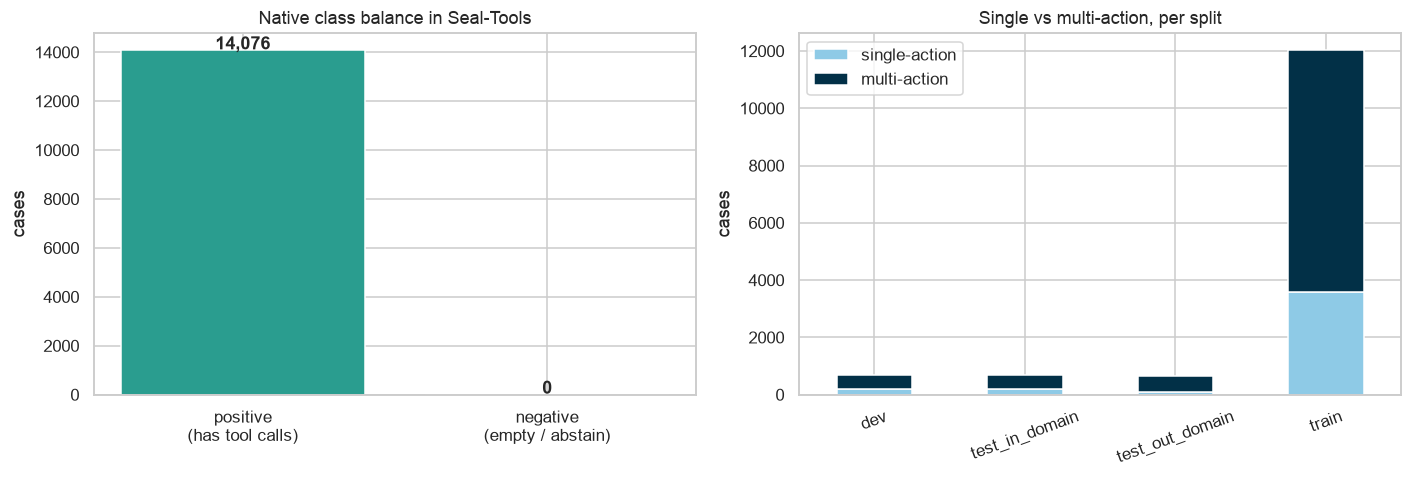

In [33]:
# Positive = has >=1 call; Negative = empty calling list
positives = int((df["arity"] >= 1).sum())
negatives = int((df["arity"] == 0).sum())
print(f"Native positive cases : {positives:,}")
print(f"Native negative cases : {negatives:,}   <-- Seal-Tools ships none")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: positive vs negative (native)
axes[0].bar(["positive\n(has tool calls)", "negative\n(empty / abstain)"],
            [positives, negatives], color=["#2a9d8f", "#e76f51"])
axes[0].set_title("Native class balance in Seal-Tools")
axes[0].set_ylabel("cases")
for i, v in enumerate([positives, negatives]):
    axes[0].text(i, v + 40, f"{v:,}", ha="center", fontweight="bold")

# Right: single vs multi among the positives, per split
piv = df.groupby("split")[["is_single", "is_multi"]].sum()
piv.plot(kind="bar", stacked=True, ax=axes[1],
         color=["#8ecae6", "#023047"])
axes[1].set_title("Single vs multi-action, per split")
axes[1].set_ylabel("cases")
axes[1].set_xlabel("")
axes[1].legend(["single-action", "multi-action"])
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 4. Single vs multi-action distribution

The `easy`/`difficult` id tier is almost a perfect proxy: **`easy` = single-action**, **`difficult` = multi-action**. Arity tops out at **6** calls. Notice arity **3** dominates the multi bucket while arity **2** is rare — the dataset was built to stress genuine multi-step planning, not just pairs.


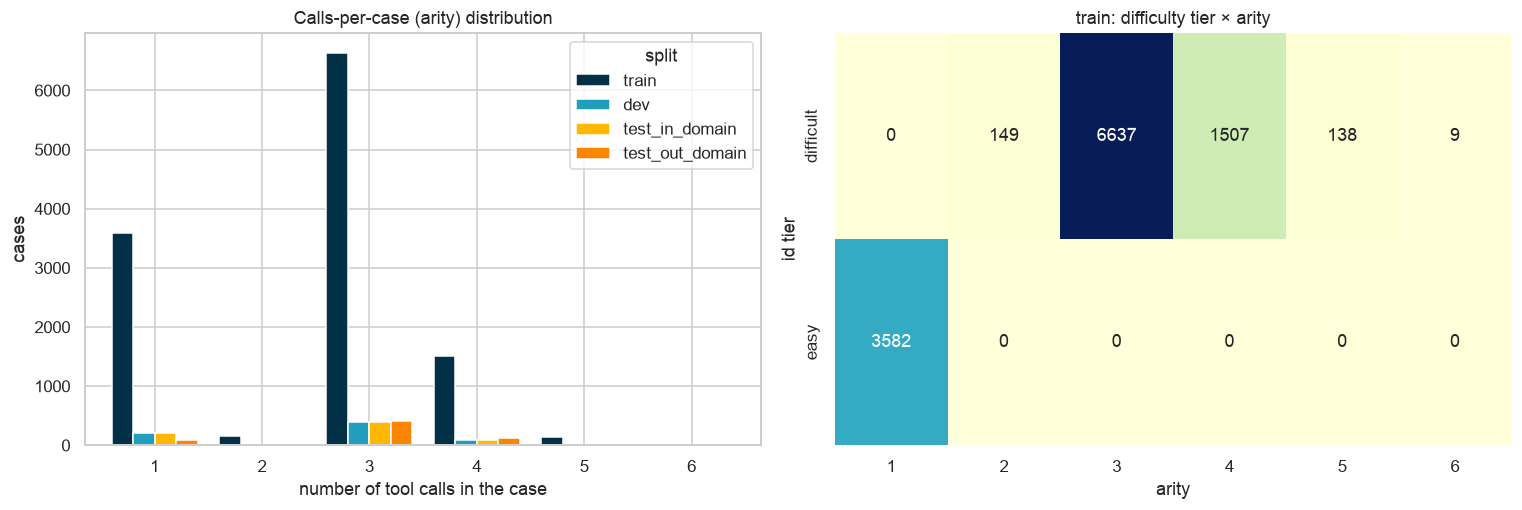

Overall arity counts: {1: 4076, 2: 174, 3: 7835, 4: 1803, 5: 170, 6: 18}
single-action share : 29.0%
multi-action share  : 71.0%


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# Arity histogram (all splits), grouped bars per split
arity_tab = (df.groupby(["arity", "split"]).size()
               .unstack(fill_value=0)
               .reindex(columns=list(SPLITS)))
arity_tab.plot(kind="bar", ax=axes[0], width=0.8,
               color=["#023047", "#219ebc", "#ffb703", "#fb8500"])
axes[0].set_title("Calls-per-case (arity) distribution")
axes[0].set_xlabel("number of tool calls in the case")
axes[0].set_ylabel("cases")
axes[0].tick_params(axis="x", rotation=0)

# Difficulty tier vs arity cross-tab (train)
ct = pd.crosstab(df.query("split=='train'")["difficulty"],
                 df.query("split=='train'")["arity"])
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1], cbar=False)
axes[1].set_title("train: difficulty tier × arity")
axes[1].set_xlabel("arity")
axes[1].set_ylabel("id tier")
plt.tight_layout()
plt.show()

overall = df["arity"].value_counts().sort_index()
print("Overall arity counts:", overall.to_dict())
print(f"single-action share : {df['is_single'].mean():.1%}")
print(f"multi-action share  : {df['is_multi'].mean():.1%}")


## 5. Dependency structure — parallel vs sequential

A multi-action case can be one of two very different things for a planner:

- **Independent / parallel** — the calls share no data; any order works. Scoring should use `order: "any"`.
- **Sequential / chained** — a later call consumes an earlier call's `API_call_N` response as an argument. Order is load-bearing; scoring should use `order: "strict"`.

Only a **minority** of multi-action cases carry an explicit data dependency, but those are the ones that make a multi-action benchmark hard. Below: how many cases have dependencies, and how deep the chains run.


multi-action cases        : 10,000
  with data dependency    : 576  (5.8%)  -> order: strict
  independent / parallel  : 9,424  (94.2%)  -> order: any


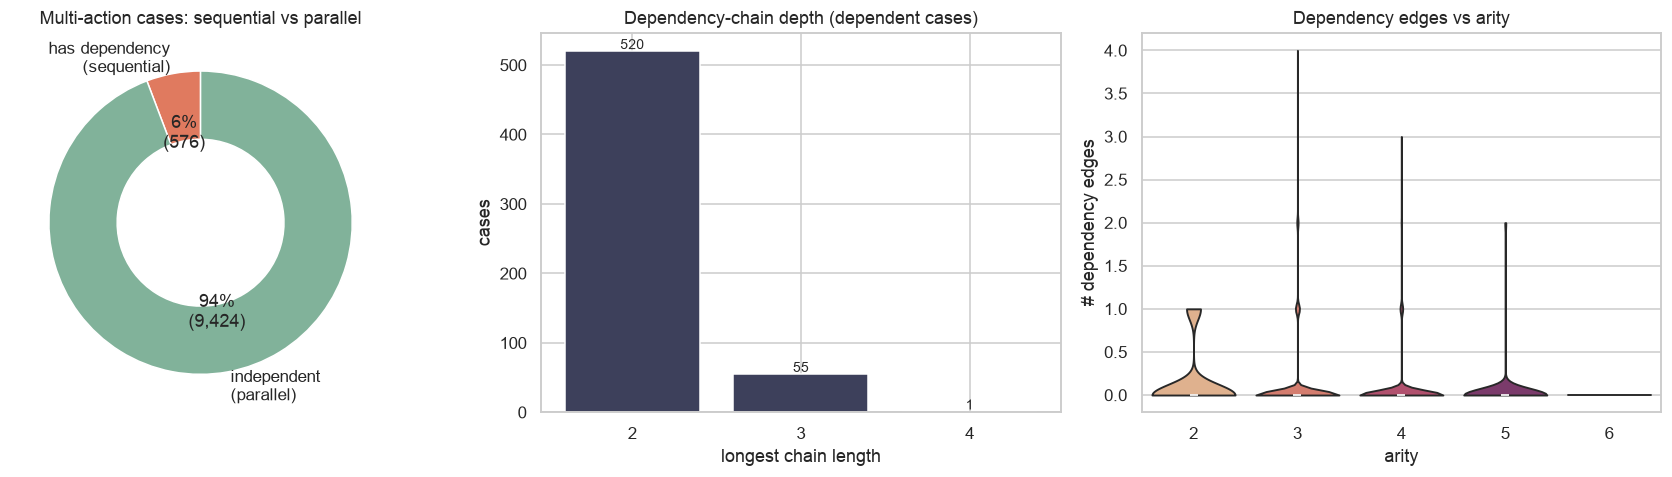

In [35]:
multi = df[df["is_multi"]]
dep = int(multi["has_dep"].sum())
indep = int((~multi["has_dep"]).sum())
print(f"multi-action cases        : {len(multi):,}")
print(f"  with data dependency    : {dep:,}  ({dep/len(multi):.1%})  -> order: strict")
print(f"  independent / parallel  : {indep:,}  ({indep/len(multi):.1%})  -> order: any")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. dependency vs independent among multi-action
axes[0].pie([dep, indep], labels=["has dependency\n(sequential)", "independent\n(parallel)"],
            autopct=lambda p: f"{p:.0f}%\n({int(round(p*len(multi)/100)):,})",
            colors=["#e07a5f", "#81b29a"], startangle=90,
            wedgeprops=dict(width=0.45))
axes[0].set_title("Multi-action cases: sequential vs parallel")

# 2. DAG depth distribution among dependent cases
depth_counts = multi[multi["has_dep"]]["dag_depth"].value_counts().sort_index()
axes[1].bar(depth_counts.index.astype(str), depth_counts.values, color="#3d405b")
axes[1].set_title("Dependency-chain depth (dependent cases)")
axes[1].set_xlabel("longest chain length")
axes[1].set_ylabel("cases")
for x, v in zip(range(len(depth_counts)), depth_counts.values):
    axes[1].text(x, v + 3, str(v), ha="center", fontsize=9)

# 3. dependency edges vs arity (how tangled)
sns.violinplot(data=multi, x="arity", y="n_dep_edges", ax=axes[2],
               hue="arity", palette="flare", legend=False, cut=0)
axes[2].set_title("Dependency edges vs arity")
axes[2].set_xlabel("arity"); axes[2].set_ylabel("# dependency edges")
plt.tight_layout()
plt.show()


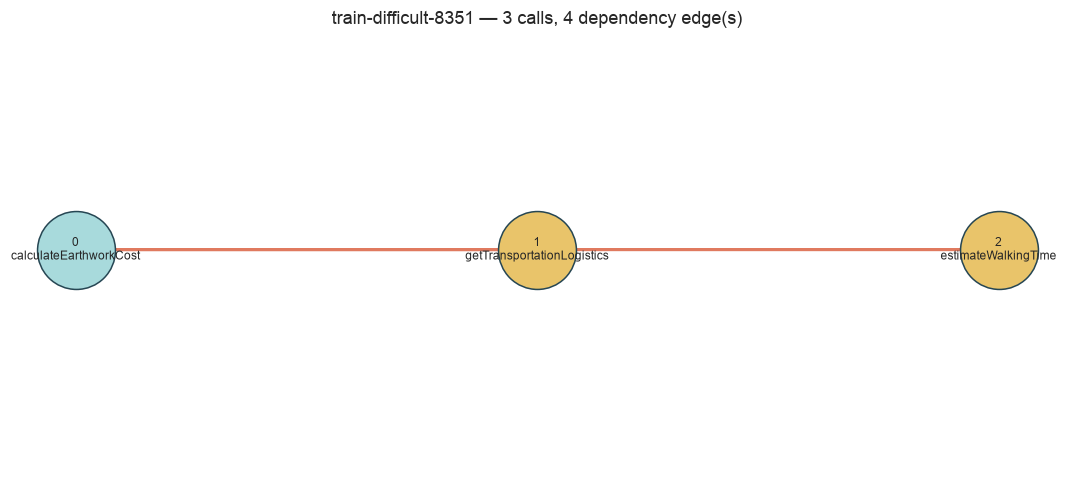

query: I need to calculate the cost of earthwork for a construction project. The area of land to be excavated is 500 square meters and the depth of excavation is 10 meters. The cost per cubic meter of earthwork is 20.0. After that, I need to retrieve the transportation logistics from the excavation site to the destination. The origin and destination are both the excavation site, and the mode of transport


In [36]:
def plot_call_dag(rec, ax=None):
    """Layered DAG of one case: nodes = calls, arrows = data dependencies."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4.5))
    calls = rec["calling"]
    edges = dependency_edges(rec)              # (consumer, producer)
    deps = defaultdict(list)
    for c, p in edges:
        deps[c].append(p)
    # level = longest producer chain, so dependents sit to the right
    level = {}
    def lvl(i):
        if i not in level:
            level[i] = max((lvl(p) for p in deps[i]), default=-1) + 1
        return level[i]
    for i in range(len(calls)):
        lvl(i)
    by_level = defaultdict(list)
    for i, L in level.items():
        by_level[L].append(i)
    pos = {}
    for L, nodes in by_level.items():
        for k, i in enumerate(sorted(nodes)):
            pos[i] = (L, -(k - (len(nodes) - 1) / 2))
    for c, p in edges:                          # draw arrows producer -> consumer
        x0, y0 = pos[p]; x1, y1 = pos[c]
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="-|>", color="#e07a5f", lw=2))
    for i, (x, y) in pos.items():
        seq = "seq" if deps[i] else "par"
        ax.scatter([x], [y], s=2600,
                   color="#e9c46a" if deps[i] else "#a8dadc",
                   edgecolors="#264653", zorder=3)
        ax.text(x, y, f"{i}\n{calls[i]['api']}", ha="center", va="center",
                fontsize=8, zorder=4)
    ax.set_title(f"{rec['id']} — {len(calls)} calls, "
                 f"{len(edges)} dependency edge(s)")
    ax.axis("off")
    return ax

# Pick a tangled example: highest dependency-edge count in train
tangled_id = df.query("split=='train'").sort_values(
    ["n_dep_edges", "arity"], ascending=False).iloc[0]["id"]
tangled = next(r for r in SPLITS["train"] if r["id"] == tangled_id)
plot_call_dag(tangled)
plt.tight_layout(); plt.show()
print("query:", tangled["query"][:400])


## 6. The tool catalog

The catalog is large — **4,076 tools** spread across **2,276 fields** — which is what makes routing hard: the correct tool is a needle in a big haystack. Tools carry typed `parameters`, a `required` subset, and typed `responses` (the outputs that feed dependencies). Below we profile parameter counts, required-vs-optional pressure, and how usage concentrates on a long tail.


catalog tools            : 4,076
tools actually called    : 4,076 (100.0%)
never-called tools       : 0
median params per tool   : 2
tools with all-required  : 54.9%


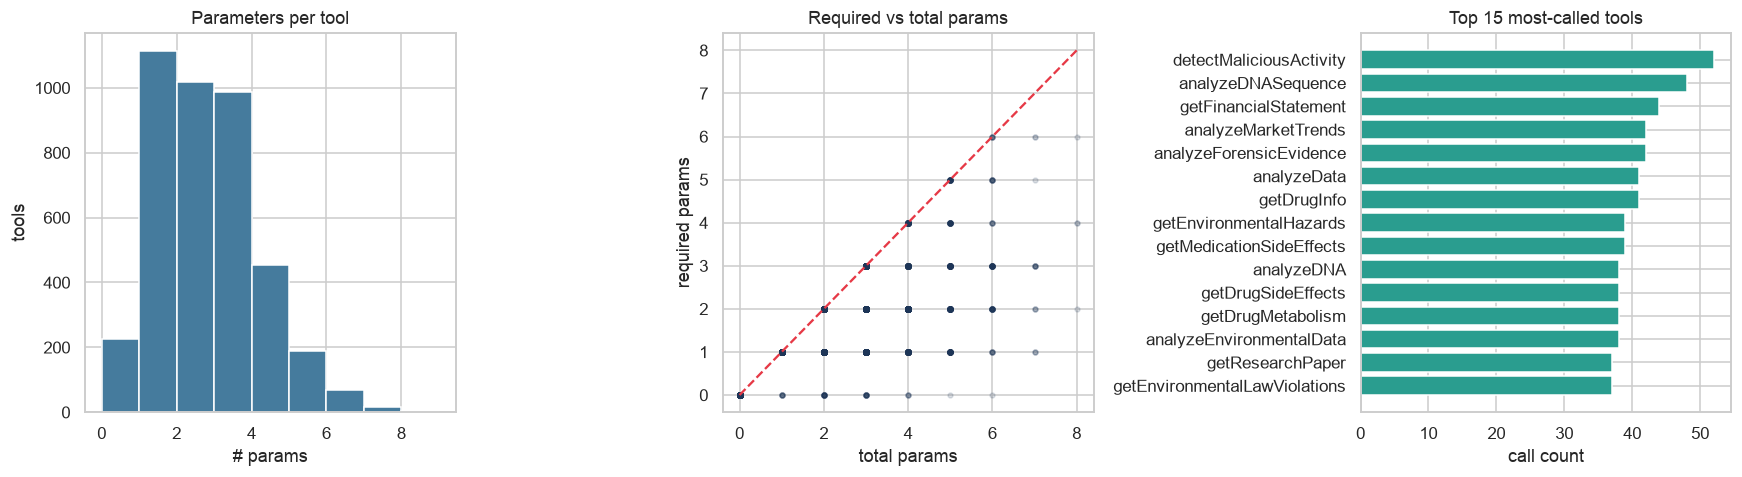

In [37]:
tool_df = pd.DataFrame([{
    "api_name": t["api_name"],
    "field": t.get("field", ""),
    "domain": (t.get("field", "") or "/").split("/")[0],
    "n_params": len(t.get("parameters", {})),
    "n_required": len(t.get("required", [])),
    "n_responses": len(t.get("responses", {})),
} for t in tools])

# usage frequency across ALL splits
usage = Counter(c["api"] for recs in SPLITS.values() for r in recs for c in r["calling"])
tool_df["uses"] = tool_df["api_name"].map(lambda a: usage.get(a, 0))
covered = (tool_df["uses"] > 0).sum()
print(f"catalog tools            : {len(tool_df):,}")
print(f"tools actually called    : {covered:,} ({covered/len(tool_df):.1%})")
print(f"never-called tools       : {len(tool_df) - covered:,}")
print(f"median params per tool   : {tool_df['n_params'].median():.0f}")
print(f"tools with all-required  : {(tool_df['n_params'] == tool_df['n_required']).mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(tool_df["n_params"], bins=range(0, tool_df["n_params"].max() + 2),
             color="#457b9d", edgecolor="white")
axes[0].set_title("Parameters per tool"); axes[0].set_xlabel("# params"); axes[0].set_ylabel("tools")

axes[1].scatter(tool_df["n_params"], tool_df["n_required"], alpha=0.15, color="#1d3557", s=10)
axes[1].plot([0, tool_df["n_params"].max()], [0, tool_df["n_params"].max()], "--", color="#e63946")
axes[1].set_title("Required vs total params"); axes[1].set_xlabel("total params"); axes[1].set_ylabel("required params")

top = tool_df.sort_values("uses", ascending=False).head(15)
axes[2].barh(top["api_name"][::-1], top["uses"][::-1], color="#2a9d8f")
axes[2].set_title("Top 15 most-called tools"); axes[2].set_xlabel("call count")
plt.tight_layout(); plt.show()


## 7. Flattening multi-action cases

To reason about the plan at the call level (and to feed a step-by-step scorer), we **flatten** each case into one row per call. Each row keeps its `case_id`, `step` index, the `api`, its `parameters`, and — importantly — the resolved `depends_on` step indices (from `API_call_N` references). This is the tabular form a multi-action runner would iterate over.


In [38]:
def flatten_case(rec):
    """One row per call, with resolved depends_on step indices."""
    producer_of = {}
    out = []
    for step, call in enumerate(rec["calling"]):
        depends_on = sorted({
            producer_of[v] for v in call["parameters"].values()
            if isinstance(v, str) and REF.match(v) and v in producer_of
        })
        out.append({
            "case_id": rec["id"],
            "step": step,
            "api": call["api"],
            "parameters": call["parameters"],
            "produces": call.get("responses", []),
            "depends_on": depends_on,
            "is_root": not depends_on,
        })
        for r in call.get("responses", []):
            producer_of[r] = step
    return out

flat = pd.DataFrame(
    [row for r in SPLITS["train"] for row in flatten_case(r)]
)
print(f"{len(flat):,} call-rows flattened from {flat['case_id'].nunique():,} train cases")

# Show the flattened view of one dependent case
demo = next(r for r in SPLITS["train"]
            if len(r["calling"]) >= 3 and has_dependency(r))
print(f"\nFlattened view of {demo['id']}:")
flat_demo = pd.DataFrame(flatten_case(demo))
flat_demo[["step", "api", "depends_on", "is_root", "parameters"]]


30,563 call-rows flattened from 12,022 train cases

Flattened view of train-difficult-3583:


,step,api,depends_on,is_root,parameters
0,0,checkLoyaltyStatus,[],True,"{'customer_id': 'customer123', 'loyalty_program': 'Platinum'}"
1,1,getCustomerProfile,[0],False,{'customer_id': 'API_call_0'}
2,2,getPharmaceuticalPrice,[],True,{'product_name': 'Lipitor'}


## 7b. Casting a Seal-Tools tool → a TypeAgent **schema**

Before a case can be scored, its actions need a **schema** to live in. TypeAgent's benchmark stores each schema two ways (see `TranslationBenchBenchmarkSchema` in `synthesizer/benchmark.ts`):

1. an **OpenAI function-tool** JSON (`tools[].function` — `name` + JSON-Schema `parameters`), which is what the model is prompted with, and
2. the **native TypeAgent action type** (a TypeScript union of `{ actionName; parameters }` types), which is what the dispatcher actually translates into.

A Seal-Tools `tool.jsonl` entry carries everything both forms need: `api_name` → action name, `parameters`/`required` → the parameter object, `api_description` → the doc string. The only real work is mapping the loose Seal-Tools type strings (`str`, `int`, `float`, `bool`, `list`, `dict`) onto JSON-Schema / TypeScript types. The two casts below do exactly that.


In [39]:
# Seal-Tools type strings -> JSON-Schema types (for the OpenAI function-tool form)
JSON_TYPE = {"str": "string", "string": "string",
             "int": "integer", "integer": "integer",
             "float": "number", "number": "number", "double": "number",
             "bool": "boolean", "boolean": "boolean",
             "list": "array", "array": "array",
             "dict": "object", "object": "object"}

def tool_to_openai_function(tool):
    """Cast a Seal-Tools catalog entry to an OpenAI function-tool (the
    `tools[].function` shape TypeAgent stores per schema)."""
    props, required = {}, tool.get("required", [])
    for name, spec in tool.get("parameters", {}).items():
        jtype = JSON_TYPE.get(str(spec.get("type", "str")).lower(), "string")
        p = {"type": jtype}
        if spec.get("description"):
            p["description"] = spec["description"]
        if jtype == "array":
            p["items"] = {"type": "string"}
        props[name] = p
    return {
        "type": "function",
        "function": {
            "name": tool["api_name"],
            "description": tool.get("api_description", ""),
            "parameters": {
                "type": "object",
                "properties": props,
                "required": list(required),
                "additionalProperties": False,
            },
        },
    }

example_tool = tool_by_name["checkLoyaltyStatus"]
print("── Seal-Tools tool → OpenAI function-tool (schema.tools[]) ──")
print(json.dumps(tool_to_openai_function(example_tool), indent=2))


── Seal-Tools tool → OpenAI function-tool (schema.tools[]) ──
{
  "type": "function",
  "function": {
    "name": "checkLoyaltyStatus",
    "description": "Check the loyalty status of a customer",
    "parameters": {
      "type": "object",
      "properties": {
        "customer_id": {
          "type": "string",
          "description": "The ID of the customer to check the loyalty status for (e.g., customer123)"
        },
        "loyalty_program": {
          "type": "string",
          "description": "The loyalty program to check the customer's status in (e.g., Gold, Silver, Platinum)"
        }
      },
      "required": [
        "customer_id"
      ],
      "additionalProperties": false
    }
  }
}


In [40]:
# Seal-Tools type strings -> TypeScript types (for the native TypeAgent action schema)
TS_TYPE = {"str": "string", "string": "string",
           "int": "number", "integer": "number", "float": "number",
           "number": "number", "double": "number",
           "bool": "boolean", "boolean": "boolean",
           "list": "string[]", "array": "string[]",
           "dict": "Record<string, unknown>", "object": "Record<string, unknown>"}

def _pascal(name):
    return name[:1].upper() + name[1:]

def tool_to_ts_action(tool):
    """Cast a Seal-Tools tool to a native TypeAgent action type."""
    required = set(tool.get("required", []))
    lines = [f"// {tool.get('api_description','').strip()}",
             f"export type {_pascal(tool['api_name'])}Action = {{",
             f'    actionName: "{tool["api_name"]}";',
             "    parameters: {"]
    for name, spec in tool.get("parameters", {}).items():
        ts = TS_TYPE.get(str(spec.get("type", "str")).lower(), "string")
        opt = "" if name in required else "?"
        desc = spec.get("description", "")
        lines.append(f"        {name}{opt}: {ts};" + (f"  // {desc}" if desc else ""))
    lines += ["    };", "};"]
    return "\n".join(lines)

def build_typeagent_schema(tools_subset, schema_name=SEAL_SCHEMA):
    """Assemble the two-part TranslationBenchBenchmarkSchema for a tool subset."""
    return {
        "schemaName": schema_name,
        "description": "Seal-Tools API catalog cast into a TypeAgent schema.",
        "tools": [tool_to_openai_function(t) for t in tools_subset],
    }

# Native TypeScript action for one tool
print("── Seal-Tools tool → native TypeAgent action type (TypeScript) ──")
print(tool_to_ts_action(example_tool))

# Full schema for exactly the tools a case touches (the demo dependency case)
demo_apis = [c["api"] for c in demo["calling"]]
demo_tools = [tool_by_name[a] for a in dict.fromkeys(demo_apis)]  # dedup, keep order
schema = build_typeagent_schema(demo_tools)
print(f"\n── TypeAgent schema '{schema['schemaName']}' hosting {len(schema['tools'])} tools "
      f"for case {demo['id']} ──")
print(json.dumps(schema, indent=2)[:1400], "...")

print("\n── native action union for the same case ──")
print(f"export type SealToolsAction =\n    | " +
      "\n    | ".join(f"{_pascal(a)}Action" for a in dict.fromkeys(demo_apis)) + ";")


── Seal-Tools tool → native TypeAgent action type (TypeScript) ──
// Check the loyalty status of a customer
export type CheckLoyaltyStatusAction = {
    actionName: "checkLoyaltyStatus";
    parameters: {
        customer_id: string;  // The ID of the customer to check the loyalty status for (e.g., customer123)
        loyalty_program?: string;  // The loyalty program to check the customer's status in (e.g., Gold, Silver, Platinum)
    };
};

── TypeAgent schema 'sealtools' hosting 3 tools for case train-difficult-3583 ──
{
  "schemaName": "sealtools",
  "description": "Seal-Tools API catalog cast into a TypeAgent schema.",
  "tools": [
    {
      "type": "function",
      "function": {
        "name": "checkLoyaltyStatus",
        "description": "Check the loyalty status of a customer",
        "parameters": {
          "type": "object",
          "properties": {
            "customer_id": {
              "type": "string",
              "description": "The ID of the customer to check

## 8. Translation demo — Seal-Tools → TypeAgent multi-action case

TypeAgent's benchmark case (see `TranslationBenchBenchmarkCaseRecord` in `synthesizer/benchmark.ts`) is:

```
case → { id, activeSchemas, targetAction, seed, generalizations[] }
seed / generalization (a "probe") → { utterance, expectedActions[], order, parameterScore[] }
expectedAction → { schemaName, actionName, parameters }
```

Today the synthesizer pins each probe to **exactly one** expected action (`actionShape.ts`, `mode: "simple"`). A Seal-Tools case maps cleanly onto the **`mode: "multi"`** shape that is still reserved:

| Seal-Tools | TypeAgent |
|---|---|
| `query` | probe `utterance` |
| each `calling[i].api` | an `expectedAction.actionName` (schema = synthetic `sealtools`) |
| `calling[i].parameters` | `expectedAction.parameters` |
| has `API_call_N` dependency? | `order: "strict"` — else `order: "any"` |
| a call's `API_call_N` reference | a cross-action `${step<k>.result}` placeholder |

The mapping below emits a runnable multi-action probe. It also lifts the dependency into an explicit `order` and rewrites reference args so a scorer can tell "chained" from "unordered".


In [41]:
SEAL_SCHEMA = "sealtools"   # one synthetic schema hosting all Seal-Tools APIs

def to_expected_actions(rec):
    """Map Seal-Tools calls to ordered TypeAgent expectedActions, rewriting
    API_call_N references into cross-step ${step<k>.result} placeholders."""
    producer_of = {}
    actions = []
    for step, call in enumerate(rec["calling"]):
        params = {}
        for k, v in call["parameters"].items():
            if isinstance(v, str) and REF.match(v) and v in producer_of:
                params[k] = f"${{step{producer_of[v]}.result}}"   # data-flow ref
            else:
                params[k] = v
        actions.append({
            "schemaName": SEAL_SCHEMA,
            "actionName": call["api"],
            "parameters": params,
        })
        for r in call.get("responses", []):
            producer_of[r] = step
    return actions

def translate_case(rec, active_schemas=(SEAL_SCHEMA,)):
    actions = to_expected_actions(rec)
    ordered = has_dependency(rec)          # dependency => order matters
    probe = {
        "utterance": rec["query"],
        "expectedActions": actions,
        "order": "strict" if ordered else "any",
        "parameterScore": [
            {"defaultMode": "exact", "fields": {}} for _ in actions
        ],
    }
    return {
        "recordType": "case",
        "version": 1,
        "id": f"sealtools-{rec['id']}",
        "activeSchemas": list(active_schemas),
        "targetAction": {
            "schemaName": SEAL_SCHEMA,
            "actionName": actions[0]["actionName"],
        },
        "explainer": {"valueInRequest": True, "noReferences": not ordered},
        "seed": probe,
        "generalizations": [],
        "dimensions": {
            "source": "seal-tools",
            "arity": len(actions),
            "shape": "multi" if len(actions) > 1 else "simple",
            "dependency": "sequential" if ordered else "parallel",
        },
    }

# Demo A: a single-action case -> simple probe
print("── translated SINGLE-action case ──")
print(json.dumps(translate_case(single), indent=2))


── translated SINGLE-action case ──
{
  "recordType": "case",
  "version": 1,
  "id": "sealtools-train-easy-0",
  "activeSchemas": [
    "sealtools"
  ],
  "targetAction": {
    "schemaName": "sealtools",
    "actionName": "analyzeEvidence"
  },
  "explainer": {
    "valueInRequest": true,
    "noReferences": true
  },
  "seed": {
    "utterance": "Analyze the fabric sample using the microscopy method to obtain evidence of type 'iSYSgFgqKb'.",
    "expectedActions": [
      {
        "schemaName": "sealtools",
        "actionName": "analyzeEvidence",
        "parameters": {
          "evidence_type": "iSYSgFgqKb",
          "method": "microscopy",
          "sample": "fabric sample"
        }
      }
    ],
    "order": "any",
    "parameterScore": [
      {
        "defaultMode": "exact",
        "fields": {}
      }
    ]
  },
  "generalizations": [],
  "dimensions": {
    "source": "seal-tools",
    "arity": 1,
    "shape": "simple",
    "dependency": "parallel"
  }
}


In [42]:
# Demo B: a multi-action case WITH a dependency -> strict, ordered probe with ${stepK.result}
print("── translated MULTI-action case (sequential / order: strict) ──")
print(json.dumps(translate_case(demo), indent=2))


── translated MULTI-action case (sequential / order: strict) ──
{
  "recordType": "case",
  "version": 1,
  "id": "sealtools-train-difficult-3583",
  "activeSchemas": [
    "sealtools"
  ],
  "targetAction": {
    "schemaName": "sealtools",
    "actionName": "checkLoyaltyStatus"
  },
  "explainer": {
    "valueInRequest": true,
    "noReferences": false
  },
  "seed": {
    "utterance": "Please check the loyalty status and customer profile of customer123 who is enrolled in the Platinum loyalty program. Then retrieve the price information for the pharmaceutical product Lipitor.",
    "expectedActions": [
      {
        "schemaName": "sealtools",
        "actionName": "checkLoyaltyStatus",
        "parameters": {
          "customer_id": "customer123",
          "loyalty_program": "Platinum"
        }
      },
      {
        "schemaName": "sealtools",
        "actionName": "getCustomerProfile",
        "parameters": {
          "customer_id": "${step0.result}"
        }
      },
      

### 8b. Synthesizing the missing negatives

Because Seal-Tools ships no negatives, a TypeAgent fairness set needs them synthesized. Three fair, hard negative *kinds* (matching the `negativeKind` dimension already used in `benchmark-approved-100.jsonl`):

- **`pure_refusal`** — the user explicitly declines the task ("Actually, don't call anything.") → `expectedActions: []`.
- **`out_of_catalog`** — a plausible request for a capability **no tool provides** → `expectedActions: []`.
- **`under_specified`** — the intent is real but too vague to bind parameters, so the fair answer is to ask, not act → `expectedActions: []`.

The template below derives a refusal negative from any positive case so positives and negatives share vocabulary (that is what keeps the negative *hard* rather than trivially detectable). Real generation should route through the existing `synthesizer/negativeFairness.ts` + quality verifier — this is the shape, not the production path.


In [43]:
def synth_negative(rec, kind="pure_refusal"):
    """Return a TypeAgent negative probe (expectedActions == []) from a positive."""
    apis = ", ".join(c["api"] for c in rec["calling"])
    utter = {
        "pure_refusal":
            f"Actually, never mind — don't run {apis} or anything else. Leave it.",
        "out_of_catalog":
            "Physically drive to the office and water the plants on my desk.",
        "under_specified":
            "Just handle the usual thing for me, you know the one.",
    }[kind]
    return {
        "recordType": "case",
        "version": 1,
        "id": f"sealtools-{rec['id']}-neg-{kind}",
        "activeSchemas": [SEAL_SCHEMA],
        "targetAction": {"schemaName": SEAL_SCHEMA,
                         "actionName": rec["calling"][0]["api"]},
        "explainer": {"valueInRequest": False, "noReferences": True},
        "seed": {
            "utterance": utter,
            "expectedActions": [],            # <-- fair negative: correct answer is "do nothing"
            "order": "any",
        },
        "generalizations": [],
        "dimensions": {"source": "seal-tools", "role": "negative",
                       "negativeKind": kind},
    }

for kind in ("pure_refusal", "out_of_catalog", "under_specified"):
    print(f"── negative ({kind}) ──")
    print(json.dumps(synth_negative(demo, kind), indent=2))
    print()


── negative (pure_refusal) ──
{
  "recordType": "case",
  "version": 1,
  "id": "sealtools-train-difficult-3583-neg-pure_refusal",
  "activeSchemas": [
    "sealtools"
  ],
  "targetAction": {
    "schemaName": "sealtools",
    "actionName": "checkLoyaltyStatus"
  },
  "explainer": {
    "valueInRequest": false,
    "noReferences": true
  },
  "seed": {
    "utterance": "Actually, never mind \u2014 don't run checkLoyaltyStatus, getCustomerProfile, getPharmaceuticalPrice or anything else. Leave it.",
    "expectedActions": [],
    "order": "any"
  },
  "generalizations": [],
  "dimensions": {
    "source": "seal-tools",
    "role": "negative",
    "negativeKind": "pure_refusal"
  }
}

── negative (out_of_catalog) ──
{
  "recordType": "case",
  "version": 1,
  "id": "sealtools-train-difficult-3583-neg-out_of_catalog",
  "activeSchemas": [
    "sealtools"
  ],
  "targetAction": {
    "schemaName": "sealtools",
    "actionName": "checkLoyaltyStatus"
  },
  "explainer": {
    "valueInReques

### 8c. Export a balanced multi-action sample

Assemble a small, balanced JSONL: multi-action positives from `test_in_domain` plus one synthesized negative each. This is the exact record shape a TypeAgent multi-action runner would consume once `mode: "multi"` lands.


In [45]:
# Prefer dependent (sequential) cases first so the sample exercises order: strict,
# then fill with independent multi-action cases.
multi_cases = [r for r in SPLITS["test_in_domain"] if len(r["calling"]) > 1]
multi_cases.sort(key=lambda r: (not has_dependency(r), len(r["calling"])))
sample_multi = multi_cases[:25]

records = []
for i, r in enumerate(sample_multi):
    records.append(translate_case(r))
    records.append(synth_negative(r, kind=("pure_refusal", "out_of_catalog",
                                           "under_specified")[i % 3]))

out_path = DATA_DIR / "typeagent-multi-action-sample.jsonl"
with open(out_path, "w") as f:
    for rec in records:
        f.write(json.dumps(rec) + "\n")

n_pos = sum(1 for r in records if r["seed"]["expectedActions"])
n_neg = sum(1 for r in records if not r["seed"]["expectedActions"])
n_strict = sum(1 for r in records if r["seed"]["order"] == "strict")
print(f"wrote {len(records)} records -> {out_path.relative_to(NB_DIR)}")
print(f"  positives     : {n_pos}")
print(f"  negatives     : {n_neg}")
print(f"  order=strict  : {n_strict}")
print("\nfirst record preview:")
print(json.dumps(records[0], indent=2)[:900])


wrote 50 records -> data/seal-tools/typeagent-multi-action-sample.jsonl
  positives     : 25
  negatives     : 25
  order=strict  : 25

first record preview:
{
  "recordType": "case",
  "version": 1,
  "id": "sealtools-test_in_domain-difficult-225",
  "activeSchemas": [
    "sealtools"
  ],
  "targetAction": {
    "schemaName": "sealtools",
    "actionName": "getWildlifeSpecies"
  },
  "explainer": {
    "valueInRequest": true,
    "noReferences": false
  },
  "seed": {
    "utterance": "I am interested in learning about wildlife species in African forests and conservation projects related to them. Please provide me with a list of wildlife species found in African forests. After that, give me detailed information about the conservation projects associated with these species.",
    "expectedActions": [
      {
        "schemaName": "sealtools",
        "actionName": "getWildlifeSpecies",
        "parameters": {
          "habitat": "forest",
          "location": "Africa"
        }
    

## 9. Findings & what to do next

**Dataset shape (all splits, 14,076 cases)**
- **Positives: 14,076 (100%). Negatives: 0.** Seal-Tools never tests abstention — we must synthesize the negative half for a fair TypeAgent set (§8b).
- **~71% multi-action, ~29% single-action.** The `easy`/`difficult` id tier is a clean single/multi proxy. Arity runs 1–6; arity **3** is the mode of the multi bucket.
- **Dependencies are the minority but the hard part.** Only **~6%** of multi-action cases chain data (`API_call_N` reused as an argument); those need `order: "strict"`. The rest are independent parallel calls (`order: "any"`). Chains are shallow (depth 2–3).
- **Big catalog, long tail.** 4,076 tools over 2,276 fields; each tool is used only a handful of times, so routing the right tool is a needle-in-haystack problem.

**Fit into TypeAgent**
- A Seal-Tools case → a multi-action **probe** with an ordered `expectedActions[]` (§8). This is exactly the `mode: "multi"` shape reserved in `actionShape.ts` (`assertTranslationBenchExpectedActionArity` already allows the negative/positive split; the arity-1 guard is what must relax to `maxActionsPerProbe > 1`).
- Map dependency → `order`: **strict** when any call consumes a prior response, else **any**. Rewrite `API_call_N` args into a `${step<k>.result}` cross-action reference so the scorer can distinguish a real chain from a lucky order.
- **Recommended slice for a first multi-action run:** all single-action cases (regression parity with today's simple mode) + arity-2/3 dependent cases (the interesting new signal), balanced with synthesized `pure_refusal` / `out_of_catalog` / `under_specified` negatives.

**Concrete next steps in this package**
1. Lift the arity-1 guard in `actionShape.ts` for `mode: "multi"` (currently hard-rejected).
2. Add a `sealtools` source adapter under `synthesizer/adapters/` that emits the records from §8.
3. Extend the runner's scorer to honor `order: "strict"` and the `${step.result}` references.
4. Generate negatives via the existing `negativeFairness.ts` + quality verifier, not the inline templates here.

The exported `data/seal-tools/typeagent-multi-action-sample.jsonl` is a ready-to-inspect example of the target record shape.


## 10. How Seal-Tools grades — and why order barely matters

Straight from the repo grader (`LLM_Evaluation/src/llm_tools/evaluation/calculate.py`, `calculate_score_ToolLearning`). Three numbers per run:

1. **`AMOUNT`** — the *format-valid rate*: fraction of predictions that parse at all (`predict[0] != -1`). A JSON-parse gate, nothing more.
2. **API `P` / `R` / `F1`** — for each predicted call it scans the gold list for the **first** call with the same `api` name and counts a hit. This is a **bag/multiset match — completely order-independent**. No positional check, no dependency check.
3. **Param `P` / `R` / `F1`** — for a matched api, count params where the name matches **and** `str(pred_value) == str(gold_value)` (exact string equality, order-independent inside the dict).

**So the answers to your questions:**

- **Parallel vs sequential?** By *explicit data dependency* (a later call reuses an earlier `API_call_N` as an argument): only **5.8% of multi-action cases are sequential**, **94.2% are independent/parallel** (§5). But the grader itself **never checks order or the dependency DAG** — it scores every case as an unordered bag of `(api, params)`. The only trace a chain leaves is the literal string `"API_call_0"` sitting in a gold param value, which the model must reproduce verbatim to earn that param's point. In grading terms, **Seal-Tools is effectively an all-parallel benchmark.**
- **How the grader works?** Format-gate → set-match APIs → exact-string-match params → micro-averaged P/R/F1. No normalization, no partial credit, no ordering, no abstention (there are no negatives to abstain on).

The next cell reimplements it faithfully and *proves* the order-independence by shuffling calls and getting the identical score.


In [47]:
import random

def seal_tools_counts(gold_calls, pred_calls):
    """Faithful port of calculate_score_ToolLearning (per case).
    gold/pred are lists of {"api", "parameters"}. Order-independent bag match,
    exact str() param match. pred_calls=None models an unparseable prediction."""
    gold_api = len(gold_calls)
    gold_param = sum(len(g["parameters"]) for g in gold_calls)
    c = dict(format_ok=0, correct_api=0, predict_api=0, gold_api=gold_api,
             correct_param=0, predict_param=0, gold_param=gold_param)
    if pred_calls is None:                     # predict == -1 (bad format)
        return c
    c["format_ok"] = 1
    for p in pred_calls:
        if "api" not in p:
            continue
        c["predict_api"] += 1
        params = p["parameters"] if isinstance(p.get("parameters"), dict) else {}
        c["predict_param"] += len(params)
        gold_idx = next((i for i, g in enumerate(gold_calls)
                         if g["api"] == p["api"]), -1)     # FIRST name match
        if gold_idx != -1:
            c["correct_api"] += 1
            gparams = gold_calls[gold_idx]["parameters"]
            for name, val in params.items():
                if name in gparams and str(val) == str(gparams[name]):
                    c["correct_param"] += 1
    return c

def prf(correct, predict, gold):
    if correct * predict * gold == 0:
        return 0.0, 0.0, 0.0
    p, r = correct / predict, correct / gold
    return p, r, 2 * p * r / (p + r)

def seal_tools_score(cases_gold, cases_pred):
    """Micro-averaged AMOUNT / API-F1 / Param-F1 over a list of cases."""
    tot = Counter()
    for g, p in zip(cases_gold, cases_pred):
        for k, v in seal_tools_counts(g, p).items():
            tot[k] += v
    _, _, api_f1 = prf(tot["correct_api"], tot["predict_api"], tot["gold_api"])
    _, _, param_f1 = prf(tot["correct_param"], tot["predict_param"], tot["gold_param"])
    return {"AMOUNT": tot["format_ok"] / len(cases_gold),
            "F1_api": round(api_f1, 4), "F1_param": round(param_f1, 4)}

# Use test_in_domain gold calls as both gold and a "perfect" prediction
gold_cases = [r["calling"] for r in SPLITS["test_in_domain"]]

perfect = gold_cases                                   # exact copy
shuffled = [random.Random(0).sample(c, len(c)) for c in gold_cases]  # reorder calls
dropped  = [c[:-1] if len(c) > 1 else c for c in gold_cases]          # miss last call

print("perfect prediction :", seal_tools_score(gold_cases, perfect))
print("calls SHUFFLED     :", seal_tools_score(gold_cases, shuffled),
      "  <-- identical F1 => grader ignores order")
print("last call DROPPED  :", seal_tools_score(gold_cases, dropped),
      "  <-- recall falls, precision stays high")


perfect prediction : {'AMOUNT': 1.0, 'F1_api': 1.0, 'F1_param': 0.9994}
calls SHUFFLED     : {'AMOUNT': 1.0, 'F1_api': 1.0, 'F1_param': 0.9994}   <-- identical F1 => grader ignores order
last call DROPPED  : {'AMOUNT': 1.0, 'F1_api': 0.8382, 'F1_param': 0.836}   <-- recall falls, precision stays high


### 10b. Building the TypeAgent equivalent (and where it goes further)

TypeAgent already has every knob the Seal-Tools grader uses, plus the ones it lacks. The mapping is one-to-one:

| Seal-Tools grader | TypeAgent runner (`translationBench`) |
|---|---|
| `predict[0] != -1` format gate | probe parses to actions, else the case scores 0 |
| API bag match (order-free) | `expectedActions` with **`order: "any"`**, set match on `(schemaName, actionName)` |
| exact `str()` param match | `parameterScore.defaultMode: "exact"` |
| *(absent)* order / DAG check | **`order: "strict"`** + `${stepK.result}` refs |
| *(absent)* abstention | **negative** probes with `expectedActions: []` |
| *(absent)* soft params | `exists` / `nonempty` / `ignore` field modes |

So: set `order: "any"` + exact params and TypeAgent reproduces Seal-Tools' F1 exactly. Turn on `order: "strict"` for the 5.8% dependent cases and add negatives, and TypeAgent scores the two things Seal-Tools structurally can't — **ordering of a real dependency chain** and **knowing when not to act**. The cell below scores the same predictions both ways to show the gap.


In [49]:
PARAM_MODES = {  # TypeAgent parameterScore field modes
    "exact":    lambda pv, gv: str(pv) == str(gv),
    "nonempty": lambda pv, gv: pv not in (None, "", [], {}),
    "exists":   lambda pv, gv: True,
    "ignore":   lambda pv, gv: True,
}

def typeagent_case_pass(expected_actions, order, predicted_actions,
                        default_mode="exact"):
    """A minimal TypeAgent-style pass/fail for one probe. Mirrors the runner:
    every expected action must be matched (by schema+name+params); when
    order=='strict' the predicted sequence must preserve expected order."""
    def params_ok(exp, got):
        for name, gv in exp["parameters"].items():
            if not PARAM_MODES[default_mode](got["parameters"].get(name), gv):
                return False
        return True

    if order == "strict":
        if len(predicted_actions) != len(expected_actions):
            return False
        return all(
            e["schemaName"] == g["schemaName"] and e["actionName"] == g["actionName"]
            and params_ok(e, g)
            for e, g in zip(expected_actions, predicted_actions))
    # order == "any": bag match, every expected action found once
    remaining = list(predicted_actions)
    for e in expected_actions:
        hit = next((g for g in remaining
                    if g["schemaName"] == e["schemaName"]
                    and g["actionName"] == e["actionName"] and params_ok(e, g)), None)
        if hit is None:
            return False
        remaining.remove(hit)
    return True

# Score the dependent (sequential) cases: correct order vs reversed order,
# under order:any (Seal-Tools-like) vs order:strict (TypeAgent-stricter).
dep_cases = [translate_case(r) for r in SPLITS["test_in_domain"]
             if len(r["calling"]) > 1 and has_dependency(r)]

def batch_pass(order, mutate):
    ok = 0
    for case in dep_cases:
        exp = case["seed"]["expectedActions"]
        pred = mutate(exp)
        ok += typeagent_case_pass(exp, order, pred)
    return ok / len(dep_cases)

identity = lambda a: a
reverse  = lambda a: list(reversed(a))

print(f"dependent cases scored: {len(dep_cases)}")
print("order=any    correct order :", round(batch_pass("any", identity), 3))
print("order=any    REVERSED order:", round(batch_pass("any", reverse), 3),
      "  <-- Seal-Tools-style: still passes, order ignored")
print("order=strict correct order :", round(batch_pass("strict", identity), 3))
print("order=strict REVERSED order:", round(batch_pass("strict", reverse), 3),
      "  <-- TypeAgent catches the broken dependency chain")


dependent cases scored: 30
order=any    correct order : 1.0
order=any    REVERSED order: 1.0   <-- Seal-Tools-style: still passes, order ignored
order=strict correct order : 1.0
order=strict REVERSED order: 0.0   <-- TypeAgent catches the broken dependency chain


## 11. Modeling the `translateRequest` response — and a full Seal→TypeAgent test

**How the runner models a translation response** (`runner/runner.ts`):

1. It calls `translateRequest(evalContext, utterance, history, …, activeSchemas, …)` — the *real* dispatcher, given the case's `activeSchemas`.
2. The result is `translated.requestAction.actions`; the runner takes `entry.action` from each to get a flat list of `AppAction` = `{ schemaName, actionName, parameters }`. That list is **`rawChosenActions`**.
3. `toScoredTranslationBenchActions` derives **`chosenActions`**: drop internal **abstentions** (`dispatcher.unknown`, counted as `abstentionCount`) and, when the gold expects actions, drop **non-eval sidecars** (`chat.generateResponse`). On empty-gold (negatives) the chat/non-eval fires are *kept* so a refusal that still "does something" is caught.
4. `scoreTranslationBench(expected, chosen, order, abstentionCount, …)` returns `passed` (all expected routed + params match + counts line up + didn't fire on an abstention).

So a "response" is just an **ordered `AppAction[]`**. Failure modes it models: a thrown `unknown`-schema error → scored zero-action abstention; a translation/JSON error → `schemaValid: false`, hard 0.

The two cells below: (1) a faithful Python port of `scoreTranslationBench`, and (2) take one **Seal-Tools row** → emit the exact `metadata` + `case` records the runner ingests → simulate four `translateRequest` responses (perfect / reordered / abstain / fires-on-negative) → score each. That's the end-to-end "map a row and test TypeAgent" loop.


In [50]:
# Faithful port of runner.ts scoreTranslationBench + response modeling.
NON_EVAL = {("chat", "generateResponse")}          # sidecar, dropped on positive gold
ABSTAIN  = ("dispatcher", "unknown")               # internal abstention

def _route_matches(e, c):
    return e["schemaName"] == c["schemaName"] and e["actionName"] == c["actionName"]

def _params_match(e, c, spec=None):
    """defaultMode exact; per-field exact/nonempty/exists/ignore. Scalar params."""
    ep, cp = e.get("parameters", {}) or {}, c.get("parameters", {}) or {}
    default = (spec or {}).get("defaultMode", "exact")
    mode = lambda k: (spec or {}).get("fields", {}).get(k, default)
    for k, ev in ep.items():
        m = mode(k)
        if m == "ignore":            continue
        if m == "exists":            
            if k not in cp: return False
            continue
        if m == "nonempty":
            if cp.get(k) in (None, "", [], {}): return False
            continue
        if str(cp.get(k)) != str(ev): return False        # exact
    if default == "exact":                                # extraneous keys fail
        for k in cp:
            if mode(k) in ("ignore", "exists", "nonempty"): continue
            if k not in ep: return False
    return True

def _align_strict(expected, chosen, ps):
    routed = pm = 0
    for i in range(min(len(expected), len(chosen))):
        e, c = expected[i], chosen[i]
        if _route_matches(e, c):
            routed += 1
            if _params_match(e, c, (ps or [None]*len(expected))[i]): pm += 1
    return routed, pm

def _align_any(expected, chosen, ps):
    used, pm, routed = set(), 0, 0
    for i, e in enumerate(expected):                      # params-first pass
        j = next((k for k, c in enumerate(chosen)
                  if k not in used and _route_matches(e, c)
                  and _params_match(e, c, (ps or [None]*len(expected))[i])), None)
        if j is not None: used.add(j); pm += 1
    routed = pm
    matched_exp = set()
    # (routed-only pass for remaining expected — mirrors runner's second loop)
    for i, e in enumerate(expected):
        j = next((k for k, c in enumerate(chosen)
                  if k not in used and _route_matches(e, c)), None)
        if j is not None: used.add(j); routed += 1
    return routed, pm

def model_translate_response(actions, expected_len):
    """Mirror toScoredTranslationBenchActions: raw -> chosen + abstentionCount."""
    without_abstain = [a for a in actions
                       if (a["schemaName"], a["actionName"]) != ABSTAIN]
    abstention = len(actions) - len(without_abstain)
    chosen = without_abstain
    if expected_len > 0:                                  # drop non-eval sidecars
        chosen = [a for a in chosen
                  if (a["schemaName"], a["actionName"]) not in NON_EVAL]
    return chosen, abstention

def score_translation_bench(expected, chosen, order, abstention=0, schema_valid=True, ps=None):
    align = "any" if (len(expected) == 1 and len(chosen) > 1) else order
    routed, pm = (_align_strict if align == "strict" else _align_any)(expected, chosen, ps)
    length_ok = len(expected) == len(chosen) or (len(expected) == 1 and len(chosen) > 1)
    passed = (schema_valid and length_ok and pm == len(expected)
              and not (abstention > 0 and len(chosen) > 0))
    return {"passed": passed, "routed": routed, "paramMatches": pm,
            "expected": len(expected), "chosen": len(chosen),
            "isNegative": len(expected) == 0,
            "firedOnNegative": len(expected) == 0 and len(chosen) > 0}

print("scorer + response model ready")


scorer + response model ready


In [53]:
# ---- 1. Pick one Seal-Tools row (a dependent, multi-action test case) --------
row = next(r for r in SPLITS["test_in_domain"]
           if len(r["calling"]) >= 2 and has_dependency(r))
print("Seal-Tools row:", row["id"])
print("query:", row["query"][:160], "...\n")

# ---- 2. Build the two records the TypeAgent runner ingests -------------------
case = translate_case(row)                                 # the `case` record
used_apis = list(dict.fromkeys(c["api"] for c in row["calling"]))
schema = build_typeagent_schema([tool_by_name[a] for a in used_apis])  # `metadata` schemas

metadata_record = {"recordType": "metadata", "version": 1,
                   "name": "sealtools-smoke", "schemas": [schema]}

expected = case["seed"]["expectedActions"]
order = case["seed"]["order"]
print(f"case id      : {case['id']}")
print(f"activeSchemas: {case['activeSchemas']}")
print(f"order        : {order}   (has dependency => strict)")
print(f"expected     : {[a['actionName'] for a in expected]}")
print(f"schema tools : {[t['function']['name'] for t in schema['tools']]}\n")

# ---- 3. Simulate translateRequest responses (requestAction.actions[].action) -
def as_actions(*acts):    # what `raw = translated.requestAction.actions.map(e=>e.action)` yields
    return list(acts)

perfect   = as_actions(*expected)                                  # dispatcher nails it
reordered = as_actions(*reversed(expected))                        # right calls, wrong order
abstain   = as_actions({"schemaName": "dispatcher", "actionName": "unknown"})  # model bailed
sidecar   = as_actions(*expected, {"schemaName": "chat",           # extra chat ack
                                   "actionName": "generateResponse",
                                   "parameters": {"generatedText": "Done!"}})

for label, resp in [("perfect", perfect), ("reordered", reordered),
                    ("abstain(unknown)", abstain), ("perfect+chat sidecar", sidecar)]:
    chosen, abst = model_translate_response(resp, len(expected))
    s = score_translation_bench(expected, chosen, order, abstention=abst,
                                ps=case["seed"].get("parameterScore"))
    print(f"{label:22} chosen={len(chosen)} abst={abst} routed={s['routed']} "
          f"paramMatches={s['paramMatches']} -> passed={s['passed']}")

# ---- 4. The negative half. On empty-gold, ANY action counts as a fire, so the
# only pass is a true zero-action abstention (dispatcher.unknown / empty list).
neg = synth_negative(row, "pure_refusal")
neg_expected = neg["seed"]["expectedActions"]          # []
for label, resp in [
    ("negative: unknown (empty)", as_actions(
        {"schemaName": "dispatcher", "actionName": "unknown"})),
    ("negative: chat reply", as_actions(
        {"schemaName": "chat", "actionName": "generateResponse",
         "parameters": {"generatedText": "I won't do that."}})),
    ("negative: WRONGLY acts", as_actions(expected[0]))]:
    chosen, abst = model_translate_response(resp, len(neg_expected))
    s = score_translation_bench(neg_expected, chosen, "any", abstention=abst)
    print(f"{label:26} chosen={len(chosen)} firedOnNegative={s['firedOnNegative']} "
          f"-> passed={s['passed']}")

# ---- 5. The full records the runner ingests (metadata + case) ----------------
print("\n=== metadata record (schemas the model is prompted with) ===")
print(json.dumps(metadata_record, indent=2))
print("\n=== case record (positive) ===")
print(json.dumps(case, indent=2))


Seal-Tools row: test_in_domain-difficult-225
query: I am interested in learning about wildlife species in African forests and conservation projects related to them. Please provide me with a list of wildlife speci ...

case id      : sealtools-test_in_domain-difficult-225
activeSchemas: ['sealtools']
order        : strict   (has dependency => strict)
expected     : ['getWildlifeSpecies', 'getConservationProjectDetails']
schema tools : ['getWildlifeSpecies', 'getConservationProjectDetails']

perfect                chosen=2 abst=0 routed=2 paramMatches=2 -> passed=True
reordered              chosen=2 abst=0 routed=0 paramMatches=0 -> passed=False
abstain(unknown)       chosen=0 abst=1 routed=0 paramMatches=0 -> passed=False
perfect+chat sidecar   chosen=2 abst=0 routed=2 paramMatches=2 -> passed=True
negative: unknown (empty)  chosen=0 firedOnNegative=False -> passed=True
negative: chat reply       chosen=1 firedOnNegative=True -> passed=False
negative: WRONGLY acts     chosen=1 firedOnNe